Murali Krishna Vattikunta

Advanced Big Data and Data Mining

Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis Using Python

Dataset: Superstore Sales Dataset (Kaggle)

In [1]:
#importing required libraries

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None) # displaying all columns

In [23]:
sales_df = pd.read_csv("/Users/vattikunta/Desktop/sales_dataset.csv") # reading the data
                       

In [4]:
sales_df.head() # displaying the first 5 rows 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [24]:
sales_df['Postal Code'] = sales_df['Postal Code'].astype('Int64') # postal code is treating as float converting to int
sales_df['Sales'] = sales_df['Sales'].round(2) # rounding of 2 decimal values

In [6]:
sales_df.head() # displaying the first 5 rows after converting the postal code to int and rounding of sales to 2 decimal 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37


In [7]:
print("Rows and Columns:", sales_df.shape) # checking dataset shape

Rows and Columns: (9800, 18)


In [8]:
sales_df.columns # displaying column names

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Step 2: Data Visualization

In [9]:
sales_df['Order Date'] = pd.to_datetime(

    sales_df['Order Date'],

    format='%d/%m/%Y'

)# converting the order date from string to date

Visualization 1: Bar Chart

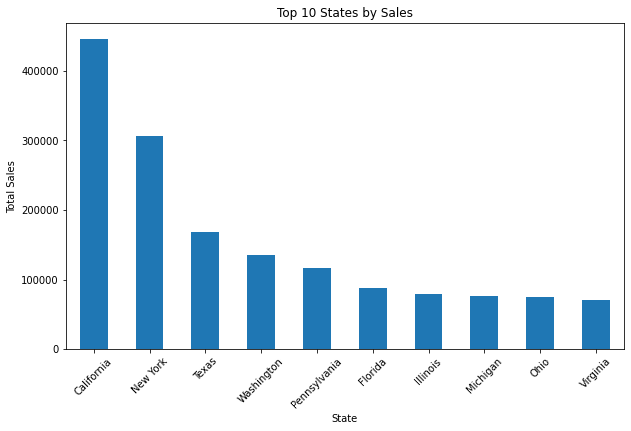

In [10]:
# top 10 states by sales

top_states = (

    sales_df.groupby('State')['Sales']

      .sum()

      .sort_values(ascending=False)

      .head(10)

)

plt.figure(figsize=(10,6))

top_states.plot(kind='bar')

plt.title('Top 10 States by Sales')

plt.xlabel('State')

plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()

California generated the highest sales among all states followed by New York. These top 10 states contribute a significant portion of total sales, indicating regional concentration of business performance.

Visualization 2: Histogram

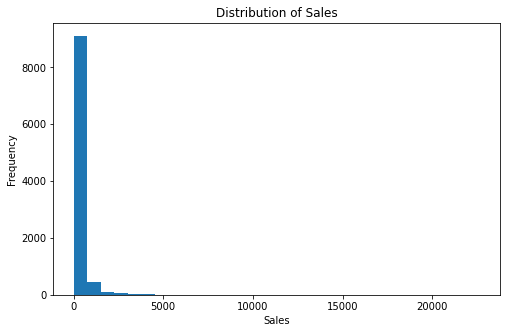

In [11]:
# Distribution of sales
plt.figure(figsize=(8,5))

plt.hist(sales_df['Sales'], bins=30)

plt.title('Distribution of Sales')

plt.xlabel('Sales')

plt.ylabel('Frequency')

plt.show()

Most sales transactions are concentrated at lower sales values. The distribution is right-skewed, indicating a few transactions with exceptionally high sales amounts.

Pie Chart: Sales by Region

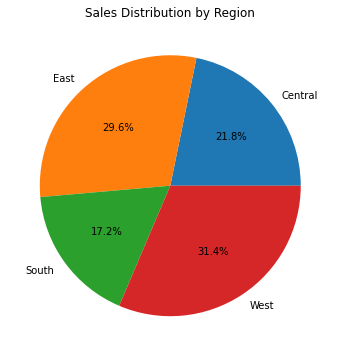

In [12]:
region_sales = sales_df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(6,6))

plt.pie(

    region_sales,

    labels=region_sales.index,

    autopct='%1.1f%%'

)

plt.title('Sales Distribution by Region')

plt.show()

The West region contributes the largest share of sales. Sales are distributed across all regions, but some regions outperform others significantly.

Line Plot (Monthly Sales Trend)

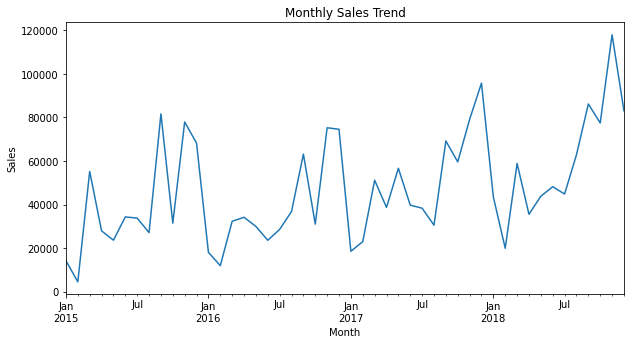

In [13]:
sales_df['Order Date'] = pd.to_datetime(sales_df['Order Date'], dayfirst=True)

monthly_sales = sales_df.groupby(

    sales_df['Order Date'].dt.to_period('M')

)['Sales'].sum()

monthly_sales.plot(figsize=(10,5))

plt.title('Monthly Sales Trend')

plt.xlabel('Month')

plt.ylabel('Sales')

plt.show()

1. Sales are fluctuating noticeably over time rather than remaining constant, which indicates seasonal or periodic changes in customer demand.
2. Several months show significant peaks in sales, suggesting periods of higher purchasing activity.
3. The overall trend help us identify strong and weak sales periods, which may be useful for inventory planning and marketing strategies.

3.1 Handling Missing Values

In [25]:
sales_df.isnull().sum() # checking missing values

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [26]:
sales_df[sales_df['Postal Code'].isnull()] # displaying rows with missing values in postal code

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,05/12/2018,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,<NA>,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,07/11/2016,09/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,<NA>,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,06/04/2017,10/04/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,<NA>,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,<NA>,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,<NA>,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,<NA>,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,<NA>,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,<NA>,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,<NA>,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,<NA>,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


In [27]:
sales_df['Postal Code'] = sales_df['Postal Code'].fillna(0) # filling missing values

In [28]:
sales_df[sales_df['Postal Code'].isnull()] # displaying rows with missing values in postal code

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales


In [29]:
sales_df.loc[2:4, 'Ship Mode'] = np.nan  # create demo missing values in shipmode columns

In [30]:
sales_df.head() # displaying shipmode with null values

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,NaN,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,11/10/2016,18/10/2016,NaN,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,11/10/2016,18/10/2016,NaN,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37


In [31]:

sales_df['Ship Mode'] = sales_df['Ship Mode'].fillna(method='ffill') # applying forward filling

/var/folders/mb/strb24w97_v59mhl5571d_l00000gn/T/ipykernel_1294/2140057342.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sales_df['Ship Mode'] = sales_df['Ship Mode'].fillna(method='ffill') # applying forward filling


In [32]:
sales_df.head() # displaying shipmode after appling forward filling values

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,11/10/2016,18/10/2016,Second Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,11/10/2016,18/10/2016,Second Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37


In [33]:
sales_df.loc[5:6, 'Ship Mode'] = np.nan  # create demo missing values in shipmode columns for backward fill

In [34]:
sales_df.iloc[3:11]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
3,4,US-2016-108966,11/10/2016,18/10/2016,Second Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,11/10/2016,18/10/2016,Second Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37
5,6,CA-2015-115812,09/06/2015,14/06/2015,NaN,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86
6,7,CA-2015-115812,09/06/2015,14/06/2015,NaN,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.28
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.15
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.90
10,11,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.18


In [35]:

sales_df['Ship Mode'] = sales_df['Ship Mode'].fillna(method='bfill') # applying forward filling

/var/folders/mb/strb24w97_v59mhl5571d_l00000gn/T/ipykernel_1294/1574114932.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sales_df['Ship Mode'] = sales_df['Ship Mode'].fillna(method='bfill') # applying forward filling


In [36]:
sales_df.iloc[3:11]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
3,4,US-2016-108966,11/10/2016,18/10/2016,Second Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,11/10/2016,18/10/2016,Second Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.28
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.15
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.90
10,11,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.18


3.2 Outlier Detection and Removal

In [37]:
#IQR calculation
Q1 = sales_df['Sales'].quantile(0.25)

Q3 = sales_df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print("Q1 =", Q1)

print("Q3 =", Q3)

print("IQR =", IQR)

print("Lower Bound =", lower_bound)

print("Upper Bound =", upper_bound)

Q1 = 17.25
Q3 = 210.60500000000002
IQR = 193.35500000000002
Lower Bound = -272.7825
Upper Bound = 500.63750000000005


In [38]:
#identifying outliers 
outliers = sales_df[

    (sales_df['Sales'] < lower_bound) |

    (sales_df['Sales'] > upper_bound)

]

print("Number of Outliers:", len(outliers))

outliers.head()

Number of Outliers: 1145


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
3,4,US-2016-108966,11/10/2016,18/10/2016,Second Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.15
10,11,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.18
11,12,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002033,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.42


In [39]:
#remove outliers
sales_df_no_outliers = sales_df[

    (sales_df['Sales'] >= lower_bound) &

    (sales_df['Sales'] <= upper_bound)

]

In [41]:
print("Original Shape:", sales_df.shape)

print("After Outlier Removal:", sales_df_no_outliers.shape)

sales_df_no_outliers.head(10)

Original Shape: (9800, 18)
After Outlier Removal: (8655, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
4,5,US-2016-108966,11/10/2016,18/10/2016,Second Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.28
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.90
12,13,CA-2018-114412,15/04/2018,20/04/2018,Standard Class,AA-10480,Andrew Allen,Consumer,United States,Concord,North Carolina,28027,South,OFF-PA-10002365,Office Supplies,Paper,Xerox 1967,15.55
13,14,CA-2017-161389,05/12/2017,10/12/2017,Standard Class,IM-15070,Irene Maddox,Consumer,United States,Seattle,Washington,98103,West,OFF-BI-10003656,Office Supplies,Binders,Fellowes PB200 Plastic Comb Binding Machine,407.98
14,15,US-2016-118983,22/11/2016,26/11/2016,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,Texas,76106,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.81


3.3 Data Reduction

In [42]:
sales_df.shape

(9800, 18)

In [43]:
# sampling 50%

sample_df = sales_df.sample(frac=0.5, random_state=42)

sample_df.shape

(4900, 18)

In [44]:
#dimension elimination

reduced_df = sample_df.drop(

    columns=[

        'Row ID',

        'Order ID',

        'Customer ID',

        'Product ID'

    ]

)

In [45]:
#after reduction

print("Before:", sales_df.shape)

print("After:", reduced_df.shape)

reduced_df.head()

Before: (9800, 18)
After: (4900, 14)


,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Product Name,Sales
532,07/09/2018,11/09/2018,Standard Class,Jasper Cacioppo,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,Tenex Chairmats For Use With Carpeted Floors,47.94
872,10/12/2015,15/12/2015,Standard Class,Sally Matthias,Consumer,United States,New York City,New York,10009,East,Office Supplies,Paper,"Adams Write n' Stick Phone Message Book, 11"" X...",11.36
1149,04/04/2016,04/04/2016,Same Day,Nat Carroll,Consumer,United States,Lansing,Michigan,48911,Central,Technology,Phones,Shocksock Galaxy S4 Armband,10.95
2287,01/06/2018,05/06/2018,Second Class,Barry Blumstein,Corporate,United States,Toledo,Ohio,43615,East,Office Supplies,Appliances,Eureka Sanitaire Multi-Pro Heavy-Duty Upright...,17.48
4038,29/12/2015,02/01/2016,Standard Class,Anthony Johnson,Corporate,United States,San Francisco,California,94110,West,Office Supplies,Paper,Xerox 1981,21.12


3.4 Data Scaling and Discretization

In [46]:
# Min-Max scaling applied to normalize Sales values between 0 and 1

sales_df['Sales_Scaled'] = (

    (sales_df['Sales'] - sales_df['Sales'].min())

    /

    (sales_df['Sales'].max() - sales_df['Sales'].min())

)

sales_df[['Sales', 'Sales_Scaled']].head()

,Sales,Sales_Scaled
0,261.96,0.011552
1,731.94,0.032313
2,14.62,0.000626
3,957.58,0.042280
4,22.37,0.000969


In [47]:
# Z-score standardization of Sales column

sales_df['Sales_Zscore'] = (

    (sales_df['Sales'] - sales_df['Sales'].mean())

    /

    sales_df['Sales'].std()

)

sales_df[['Sales', 'Sales_Zscore']].head()

,Sales,Sales_Zscore
0,261.96,0.049774
1,731.94,0.799760
2,14.62,-0.344927
3,957.58,1.159832
4,22.37,-0.332560


In [48]:
#discretization

sales_df['Sales_Category'] = pd.cut(

    sales_df['Sales'],

    bins=3,

    labels=['Low', 'Medium', 'High']

)

In [49]:
sales_df[['Sales', 'Sales_Scaled', 'Sales_Category']].head(15)

,Sales,Sales_Scaled,Sales_Category
0,261.96,0.011552,Low
1,731.94,0.032313,Low
2,14.62,0.000626,Low
3,957.58,0.042280,Low
4,22.37,0.000969,Low
5,48.86,0.002139,Low
6,7.28,0.000302,Low
7,907.15,0.040052,Low
8,18.50,0.000798,Low
9,114.90,0.005056,Low


Short Explanations for Step 3:

Missing Values: Missing Sales values were replaced using constants,forward fill and backward fill.

Outliers:
Outliers in the Sales data were identified using the Interquartile Range (IQR) method and removed to reduce the impact of extreme values on analysis.

Data Reduction:
The dataset was reduced through random sampling (50%) and by removing non-essential identifier columns to simplify analysis and improve efficiency.

Scaling and Discretization:
Min-Max scaling was applied to normalize Sales values between 0 and 1. Additionally, Sales values were discretized into Low, Medium, and High categories to enable simplified interpretation and comparative analysis.

4.1 General Overview of Data

In [50]:
sales_df.info() # dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Row ID          9800 non-null   int64   
 1   Order ID        9800 non-null   object  
 2   Order Date      9800 non-null   object  
 3   Ship Date       9800 non-null   object  
 4   Ship Mode       9800 non-null   object  
 5   Customer ID     9800 non-null   object  
 6   Customer Name   9800 non-null   object  
 7   Segment         9800 non-null   object  
 8   Country         9800 non-null   object  
 9   City            9800 non-null   object  
 10  State           9800 non-null   object  
 11  Postal Code     9800 non-null   Int64   
 12  Region          9800 non-null   object  
 13  Product ID      9800 non-null   object  
 14  Category        9800 non-null   object  
 15  Sub-Category    9800 non-null   object  
 16  Product Name    9800 non-null   object  
 17  Sales         

In [51]:
sales_df.describe() # summary statistics

,Row ID,Postal Code,Sales,Sales_Scaled,Sales_Zscore
count,9800.000000,9800.0,9800.000000,9800.000000,9.800000e+03
mean,4900.500000,55211.280918,230.769036,0.010174,1.305078e-17
std,2829.160653,32076.677954,626.651878,0.027681,1.000000e+00
min,1.000000,0.0,0.440000,0.000000,-3.675550e-01
25%,2450.750000,23223.0,17.250000,0.000743,-3.407299e-01
50%,4900.500000,57551.0,54.490000,0.002388,-2.813030e-01
75%,7350.250000,90008.0,210.605000,0.009284,-3.217741e-02
max,9800.000000,99301.0,22638.480000,1.000000,3.575783e+01


Insight

1. The dataset contains sales transaction records and multiple categorical attributes.
2. Summary statistics provide information about count, mean, standard deviation, minimum, maximum, and quartile values for numerical columns.

4.2 Central Tendency Measures: 

In [52]:
#Calculating Minimum, Maximum, Mean, Median, and Mode for Sales.

sales_min = sales_df['Sales'].min()

sales_max = sales_df['Sales'].max()

sales_mean = sales_df['Sales'].mean()

sales_median = sales_df['Sales'].median()

sales_mode = sales_df['Sales'].mode()[0]

print("Minimum:", sales_min)

print("Maximum:", sales_max)

print("Mean:", sales_mean)

print("Median:", sales_median)

print("Mode:", sales_mode)

Minimum: 0.44
Maximum: 22638.48
Mean: 230.7690357142857
Median: 54.489999999999995
Mode: 12.96


Insights: 

1. The mean represents the average sales value.
2. The median indicates the middle sales value and is less affected by outliers.
3. The mode represents the most frequently occurring sales amount.

4.3 Dispersion Measures

In [53]:
# range

sales_range = sales_max - sales_min

print("Range:", sales_range)

Range: 22638.04


In [54]:
#Quartiles and IQR

Q1 = sales_df['Sales'].quantile(0.25)

Q2 = sales_df['Sales'].quantile(0.50)

Q3 = sales_df['Sales'].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)

print("Q2 (Median):", Q2)

print("Q3:", Q3)

print("IQR:", IQR)

Q1: 17.25
Q2 (Median): 54.489999999999995
Q3: 210.60500000000002
IQR: 193.35500000000002


In [55]:
#Variance and Standard Deviation

variance = sales_df['Sales'].var()

std_dev = sales_df['Sales'].std()

print("Variance:", variance)

print("Standard Deviation:", std_dev)

Variance: 392692.5767982434
Standard Deviation: 626.6518784765935


In [56]:
print("Range:", sales_range)

print("Q1:", Q1)

print("Q2:", Q2)

print("Q3:", Q3)

print("IQR:", IQR)

print("Variance:", variance)

print("Standard Deviation:", std_dev)

Range: 22638.04
Q1: 17.25
Q2: 54.489999999999995
Q3: 210.60500000000002
IQR: 193.35500000000002
Variance: 392692.5767982434
Standard Deviation: 626.6518784765935


Insight

1. The range shows the spread between the highest and lowest sales values.
2. IQR measures the spread of the middle 50% of sales values.
3. Standard deviation indicates how much sales values vary from the average.
4. A large standard deviation suggests high variability in sales transactions.

4.4 Correlation Analysis

In [57]:
#selecting numeric columns 

numeric_sales_df = sales_df.select_dtypes(include=['number'])

numeric_sales_df.head()

,Row ID,Postal Code,Sales,Sales_Scaled,Sales_Zscore
0,1,42420,261.96,0.011552,0.049774
1,2,42420,731.94,0.032313,0.799760
2,3,90036,14.62,0.000626,-0.344927
3,4,33311,957.58,0.042280,1.159832
4,5,33311,22.37,0.000969,-0.332560


In [58]:
#correlation matrix

correlation_matrix = numeric_sales_df.corr()

correlation_matrix

,Row ID,Postal Code,Sales,Sales_Scaled,Sales_Zscore
Row ID,1.000000,0.011298,0.001151,0.001151,0.001151
Postal Code,0.011298,1.000000,-0.025756,-0.025756,-0.025756
Sales,0.001151,-0.025756,1.000000,1.000000,1.000000
Sales_Scaled,0.001151,-0.025756,1.000000,1.000000,1.000000
Sales_Zscore,0.001151,-0.025756,1.000000,1.000000,1.000000


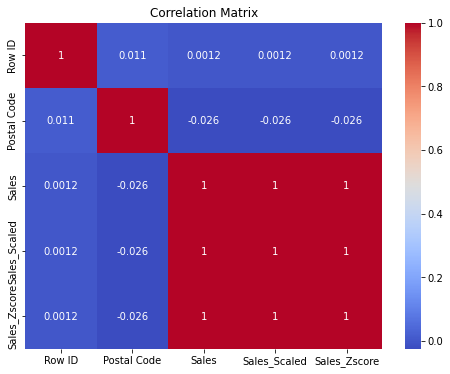

In [59]:
#Heat Map

import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(

    correlation_matrix,

    annot=True,

    cmap='coolwarm'

)

plt.title('Correlation Matrix')

plt.show()

Insight

1. Correlation values range from -1 to +1.
2. Values close to +1 indicate a strong positive relationship.
3. Values close to -1 indicate a strong negative relationship.
4. Values near 0 indicate little or no linear relationship between variables.